# Vanishing Gradients: Deep U-Net vs. Res-UNet with Residual Connections

This experiment (project_report.txt lines 208–215) demonstrates how:
- Deep plain U-Nets encounter vanishing gradients and optimization issues
- Adding residual connections (ResUNet) stabilizes training and enables deeper networks to actually learn.

We'll train both models, show loss and (most importantly) gradient norm plots, and compare segmentation results.


In [17]:
import os, glob, random
import numpy as np
import SimpleITK as sitk
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import matplotlib.pyplot as plt
from math import sqrt

DATA_ROOT = "/kaggle/input/brats2015/BRATS2015/training"
RANDOM_SEED = 42
PATCH_SIZE = (64,64,64)
N_CASES = 8
PATCHES_PER_CASE = 6
BATCH_SIZE = 2
EPOCHS = 2
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def zscore_norm(img):
    mask = img > 0
    if mask.sum() == 0:
        return (img - img.mean()) / (img.std() + 1e-8)
    else:
        mean = img[mask].mean()
        std = img[mask].std()
        return (img - mean) / (std + 1e-8)

def load_mha_case(folder):
    files = sorted(glob.glob(os.path.join(folder, "*.mha")))
    t1 = next(f for f in files if "t1." in f.lower() and not "t1c" in f.lower())
    t1ce = next(f for f in files if "t1c" in f.lower())
    t2 = next(f for f in files if "t2." in f.lower())
    flair = next(f for f in files if "flair" in f.lower())
    seg = next(f for f in files if "ot." in f.lower())
    vols = []
    for f in [t1, t2, t1ce, flair]:
        img = sitk.GetArrayFromImage(sitk.ReadImage(f)).astype(np.float32)
        img = zscore_norm(img)
        vols.append(img)
    vol = np.stack(vols, axis=0)  # [4, D, H, W]
    seg = sitk.GetArrayFromImage(sitk.ReadImage(seg)).astype(np.int16)
    return vol, seg

class BRATSPatchDataset(Dataset):
    def __init__(self, data_root, n_cases=N_CASES, patch=PATCH_SIZE, patches_per_case=PATCHES_PER_CASE):
        folders = sorted(glob.glob(os.path.join(data_root, "*/*/")))
        random.shuffle(folders)
        selected = folders[:n_cases]
        self.patch = patch
        self.patches_per_case = patches_per_case
        self.volumes, self.segs = [], []
        print(f"Loading {len(selected)} cases...")
        for case in selected:
            try:
                v, l = load_mha_case(case)
                self.volumes.append(v)
                self.segs.append(l)
            except Exception as e:
                print(f"Skipping {case} due to {e}")
        print("Done loading.")
    def __len__(self):
        return len(self.volumes) * self.patches_per_case
    def __getitem__(self, idx):
        cidx = idx // self.patches_per_case
        img4 = self.volumes[cidx]
        seg = self.segs[cidx]
        D,H,W = img4.shape[1:]
        pd,ph,pw=self.patch
        tumor_mask = (seg > 0)
        if tumor_mask.any() and random.random() < 0.7:
            tz, ty, tx = np.argwhere(tumor_mask)[np.random.randint(0, tumor_mask.sum())]
            z0 = max(0, min(int(tz) - pd//2, D-pd))
            y0 = max(0, min(int(ty) - ph//2, H-ph))
            x0 = max(0, min(int(tx) - pw//2, W-pw))
        else:
            z0 = random.randint(0, max(1, D-pd))
            y0 = random.randint(0, max(1, H-ph))
            x0 = random.randint(0, max(1, W-pw))
        patch4 = img4[:,z0:z0+pd,y0:y0+ph,x0:x0+pw]    # [4, pd, ph, pw]
        fused = patch4.mean(axis=0, keepdims=True)      # [1, pd, ph, pw]
        label = seg[z0:z0+pd,y0:y0+ph,x0:x0+pw]
        fused = torch.from_numpy(fused).float()
        label = torch.from_numpy(label).long()
        return fused, label



In [18]:
# -- Deep U-Net (No Residual Connections) --
class PlainConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv3d(in_ch, out_ch, 3, padding=1)
        self.bn1 = nn.BatchNorm3d(out_ch)
        self.conv2 = nn.Conv3d(out_ch, out_ch, 3, padding=1)
        self.bn2 = nn.BatchNorm3d(out_ch)
        self.relu = nn.ReLU(inplace=True)
    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        return x

class DeepUNetNoResidual(nn.Module):
    def __init__(self, in_ch=1, out_ch=5, base=8):
        super().__init__()
        self.stem = PlainConvBlock(in_ch, base)
        self.down1 = nn.Sequential(nn.Conv3d(base, base*2, 3, stride=2, padding=1), PlainConvBlock(base*2, base*2))
        self.down2 = nn.Sequential(nn.Conv3d(base*2, base*4, 3, stride=2, padding=1), PlainConvBlock(base*4, base*4))
        self.down3 = nn.Sequential(nn.Conv3d(base*4, base*8, 3, stride=2, padding=1), PlainConvBlock(base*8, base*8))
        self.down4 = nn.Sequential(nn.Conv3d(base*8, base*8, 3, stride=2, padding=1), PlainConvBlock(base*8, base*8))
        self.up1 = nn.ConvTranspose3d(base*8, base*4, 2, stride=2)
        self.up2 = nn.ConvTranspose3d(base*4, base*2, 2, stride=2)
        self.up3 = nn.ConvTranspose3d(base*2, base, 2, stride=2)
        self.up4 = nn.ConvTranspose3d(base, base, 2, stride=2)
        self.conv_final = nn.Conv3d(base, out_ch, 1)
    def forward(self, x):
        s0 = self.stem(x)
        d1 = self.down1(s0)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        u1 = self.up1(d4)
        u2 = self.up2(u1)
        u3 = self.up3(u2)
        u4 = self.up4(u3)
        return self.conv_final(u4)



Loading 8 cases...
Done loading.


/tmp/ipykernel_37/1901813856.py:135: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_plain = torch.cuda.amp.GradScaler(enabled=(DEVICE.type=='cuda'))
/tmp/ipykernel_37/1901813856.py:136: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_res   = torch.cuda.amp.GradScaler(enabled=(DEVICE.type=='cuda'))
/tmp/ipykernel_37/1901813856.py:168: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type=='cuda')):



Stabilized training with InstanceNorm + AMP + grad accumulation + tighter clip + deterministic eval
Training U-Net (no residuals)
Plain-IN Epoch 1: loss=0.8968 | eval_dice=0.105
Plain-IN Epoch 2: loss=0.8950 | eval_dice=0.105

Training ResUNet (residuals)


/tmp/ipykernel_37/1901813856.py:190: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type=='cuda')):


ResUNet-IN Epoch 1: loss=0.9023 | eval_dice=0.036
ResUNet-IN Epoch 2: loss=0.8937 | eval_dice=0.104


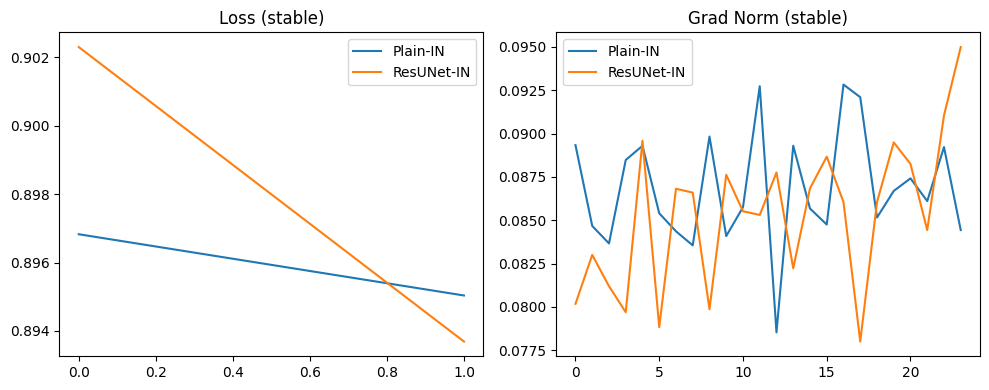

In [19]:
# Stabilized training/eval: InstanceNorm option, AMP, grad accumulation, tighter clipping, deterministic eval
import copy

USE_INSTANCE_NORM = True
ACCUM_STEPS = 2
MAX_NORM = 0.5
LR = 3e-4

# Redefine basic blocks with selectable norm for small-batch stability
Norm3d = nn.InstanceNorm3d if USE_INSTANCE_NORM else nn.BatchNorm3d

class ResidualBlock3d_IN(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv3d(in_ch, out_ch, 3, padding=1)
        self.n1 = Norm3d(out_ch, affine=True)
        self.conv2 = nn.Conv3d(out_ch, out_ch, 3, padding=1)
        self.n2 = Norm3d(out_ch, affine=True)
        self.relu = nn.ReLU(inplace=True)
        self.proj = nn.Conv3d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    def forward(self, x):
        identity = self.proj(x)
        x = self.relu(self.n1(self.conv1(x)))
        x = self.n2(self.conv2(x))
        return self.relu(x + identity)

class PlainConvBlock_IN(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv3d(in_ch, out_ch, 3, padding=1)
        self.n1 = Norm3d(out_ch, affine=True)
        self.conv2 = nn.Conv3d(out_ch, out_ch, 3, padding=1)
        self.n2 = Norm3d(out_ch, affine=True)
        self.relu = nn.ReLU(inplace=True)
    def forward(self, x):
        x = self.relu(self.n1(self.conv1(x)))
        x = self.relu(self.n2(self.conv2(x)))
        return x

class DeepUNetNoResidual_IN(nn.Module):
    def __init__(self, in_ch=1, out_ch=5, base=8):
        super().__init__()
        self.stem = PlainConvBlock_IN(in_ch, base)
        self.down1 = nn.Sequential(nn.Conv3d(base, base*2, 3, stride=2, padding=1), PlainConvBlock_IN(base*2, base*2))
        self.down2 = nn.Sequential(nn.Conv3d(base*2, base*4, 3, stride=2, padding=1), PlainConvBlock_IN(base*4, base*4))
        self.down3 = nn.Sequential(nn.Conv3d(base*4, base*8, 3, stride=2, padding=1), PlainConvBlock_IN(base*8, base*8))
        self.down4 = nn.Sequential(nn.Conv3d(base*8, base*8, 3, stride=2, padding=1), PlainConvBlock_IN(base*8, base*8))
        self.up1 = nn.ConvTranspose3d(base*8, base*4, 2, stride=2)
        self.up2 = nn.ConvTranspose3d(base*4, base*2, 2, stride=2)
        self.up3 = nn.ConvTranspose3d(base*2, base, 2, stride=2)
        self.up4 = nn.ConvTranspose3d(base, base, 2, stride=2)
        self.conv_final = nn.Conv3d(base, out_ch, 1)
    def forward(self, x):
        s0 = self.stem(x)
        d1 = self.down1(s0)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        u1 = self.up1(d4)
        u2 = self.up2(u1)
        u3 = self.up3(u2)
        u4 = self.up4(u3)
        return self.conv_final(u4)

class SimpleResUNet3D_IN(nn.Module):
    def __init__(self, in_ch=1, out_ch=5, base=8):
        super().__init__()
        self.stem = ResidualBlock3d_IN(in_ch, base)
        self.down1 = nn.Sequential(nn.Conv3d(base, base*2, 3, stride=2, padding=1), ResidualBlock3d_IN(base*2, base*2))
        self.down2 = nn.Sequential(nn.Conv3d(base*2, base*4, 3, stride=2, padding=1), ResidualBlock3d_IN(base*4, base*4))
        self.down3 = nn.Sequential(nn.Conv3d(base*4, base*8, 3, stride=2, padding=1), ResidualBlock3d_IN(base*8, base*8))
        self.down4 = nn.Sequential(nn.Conv3d(base*8, base*8, 3, stride=2, padding=1), ResidualBlock3d_IN(base*8, base*8))
        self.up1 = nn.ConvTranspose3d(base*8, base*4, 2, stride=2)
        self.up2 = nn.ConvTranspose3d(base*4, base*2, 2, stride=2)
        self.up3 = nn.ConvTranspose3d(base*2, base, 2, stride=2)
        self.up4 = nn.ConvTranspose3d(base, base, 2, stride=2)
        self.head = nn.Conv3d(base, out_ch, 1)
    def forward(self, x):
        s0 = self.stem(x)
        d1 = self.down1(s0)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        u1 = self.up1(d4)
        u2 = self.up2(u1)
        u3 = self.up3(u2)
        u4 = self.up4(u3)
        return self.head(u4)

# Deterministic evaluation dataset (center crop instead of random)
class BRATSEvalPatchDataset(Dataset):
    def __init__(self, data_root, n_cases=4, patch=PATCH_SIZE):
        folders = sorted(glob.glob(os.path.join(data_root, "*/*/")))
        selected = folders[-n_cases:]
        self.volumes, self.segs = [], []
        self.patch = patch
        for case in selected:
            try:
                v, l = load_mha_case(case)
                self.volumes.append(v)
                self.segs.append(l)
            except Exception as e:
                print(f"Skipping eval case {case}: {e}")
    def __len__(self):
        return len(self.volumes)
    def __getitem__(self, idx):
        img4 = self.volumes[idx]
        seg = self.segs[idx]
        D,H,W = img4.shape[1:]
        pd,ph,pw = self.patch
        z0 = max(0, (D - pd)//2); y0 = max(0, (H - ph)//2); x0 = max(0, (W - pw)//2)
        patch4 = img4[:, z0:z0+pd, y0:y0+ph, x0:x0+pw]
        fused = patch4.mean(axis=0, keepdims=True)
        label = seg[z0:z0+pd, y0:y0+ph, x0:x0+pw]
        return torch.from_numpy(fused).float(), torch.from_numpy(label).long()

# Build loaders
train_loader = DataLoader(BRATSPatchDataset(DATA_ROOT), batch_size=BATCH_SIZE, shuffle=True)
eval_loader  = DataLoader(BRATSEvalPatchDataset(DATA_ROOT),  batch_size=1, shuffle=False)

# Models with InstanceNorm and smaller LR, grad clipping, AMP, grad accumulation
def kaiming_init(m):
    if isinstance(m, nn.Conv3d):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            nn.init.zeros_(m.bias)

model_plain_in = DeepUNetNoResidual_IN(in_ch=1, out_ch=5, base=8).to(DEVICE)
model_res_in   = SimpleResUNet3D_IN(in_ch=1, out_ch=5, base=8).to(DEVICE)
model_plain_in.apply(kaiming_init)
model_res_in.apply(kaiming_init)

opt_plain_in = torch.optim.AdamW(model_plain_in.parameters(), lr=LR, weight_decay=1e-5, betas=(0.9, 0.99))
opt_res_in   = torch.optim.AdamW(model_res_in.parameters(),   lr=LR, weight_decay=1e-5, betas=(0.9, 0.99))
scaler_plain = torch.cuda.amp.GradScaler(enabled=(DEVICE.type=='cuda'))
scaler_res   = torch.cuda.amp.GradScaler(enabled=(DEVICE.type=='cuda'))
sched_plain  = torch.optim.lr_scheduler.CosineAnnealingLR(opt_plain_in, T_max=max(1, EPOCHS))
sched_res    = torch.optim.lr_scheduler.CosineAnnealingLR(opt_res_in,   T_max=max(1, EPOCHS))

# Utilities
def grad_norm_all(m):
    s = 0.0
    for p in m.parameters():
        if p.grad is not None:
            g = p.grad.norm()
            s += (g*g).item()
    return sqrt(s) if s>0 else 0.0

def eval_model(m):
    m.eval()
    dices = []
    with torch.no_grad():
        for xb, yb in eval_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            out = m(xb)
            dices.append(dice_score(out, yb))
    return float(np.mean(dices)) if len(dices)>0 else float('nan')

plain_loss_hist2, res_loss_hist2 = [], []
plain_grad_hist2, res_grad_hist2 = [], []

print("\nStabilized training with InstanceNorm + AMP + grad accumulation + tighter clip + deterministic eval")
print("Training U-Net (no residuals)")
for ep in range(EPOCHS):
    model_plain_in.train(); losses=[]; opt_plain_in.zero_grad(set_to_none=True)
    for i,(x,y) in enumerate(train_loader, start=1):
        x,y = x.to(DEVICE), y.to(DEVICE)
        with torch.cuda.amp.autocast(enabled=(DEVICE.type=='cuda')):
            out = model_plain_in(x)
            loss = dice_loss(out,y) / ACCUM_STEPS
        scaler_plain.scale(loss).backward()
        if i % ACCUM_STEPS == 0:
            scaler_plain.unscale_(opt_plain_in)
            torch.nn.utils.clip_grad_norm_(model_plain_in.parameters(), max_norm=MAX_NORM)
            plain_grad_hist2.append(grad_norm_all(model_plain_in))
            scaler_plain.step(opt_plain_in)
            scaler_plain.update()
            opt_plain_in.zero_grad(set_to_none=True)
        losses.append(loss.item()*ACCUM_STEPS)
    sched_plain.step()
    eval_d = eval_model(model_plain_in)
    print(f"Plain-IN Epoch {ep+1}: loss={np.mean(losses):.4f} | eval_dice={eval_d:.3f}")
    plain_loss_hist2.append(np.mean(losses))

print("\nTraining ResUNet (residuals)")
for ep in range(EPOCHS):
    model_res_in.train(); losses=[]; opt_res_in.zero_grad(set_to_none=True)
    for i,(x,y) in enumerate(train_loader, start=1):
        x,y = x.to(DEVICE), y.to(DEVICE)
        with torch.cuda.amp.autocast(enabled=(DEVICE.type=='cuda')):
            out = model_res_in(x)
            loss = dice_loss(out,y) / ACCUM_STEPS
        scaler_res.scale(loss).backward()
        if i % ACCUM_STEPS == 0:
            scaler_res.unscale_(opt_res_in)
            torch.nn.utils.clip_grad_norm_(model_res_in.parameters(), max_norm=MAX_NORM)
            res_grad_hist2.append(grad_norm_all(model_res_in))
            scaler_res.step(opt_res_in)
            scaler_res.update()
            opt_res_in.zero_grad(set_to_none=True)
        losses.append(loss.item()*ACCUM_STEPS)
    sched_res.step()
    eval_d = eval_model(model_res_in)
    print(f"ResUNet-IN Epoch {ep+1}: loss={np.mean(losses):.4f} | eval_dice={eval_d:.3f}")
    res_loss_hist2.append(np.mean(losses))

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.title("Loss (stable)"); plt.plot(plain_loss_hist2,label="Plain-IN"); plt.plot(res_loss_hist2,label="ResUNet-IN"); plt.legend()
plt.subplot(1,2,2); plt.title("Grad Norm (stable)"); plt.plot(plain_grad_hist2,label="Plain-IN"); plt.plot(res_grad_hist2,label="ResUNet-IN"); plt.legend()
plt.tight_layout(); plt.show()


Loading 8 cases...
Done loading.
Training U-Net (no residuals)
Plain Epoch 1: loss=0.8841 | eval_dice=0.194
Plain Epoch 2: loss=0.8651 | eval_dice=0.194

Training ResUNet (residuals)
ResUNet Epoch 1: loss=0.8900 | eval_dice=0.169
ResUNet Epoch 2: loss=0.8129 | eval_dice=0.190


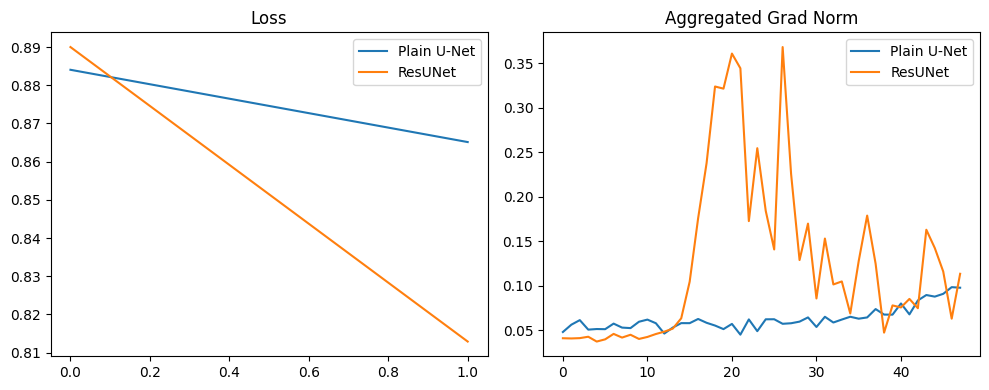

Fixed-batch Dice – Plain (last): 0.194 | ResUNet (last): 0.190


In [20]:
# 1) ResUNet with residuals (short form)
class ResidualBlock3d(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv3d(in_ch, out_ch, 3, padding=1)
        self.bn1 = nn.BatchNorm3d(out_ch)
        self.conv2 = nn.Conv3d(out_ch, out_ch, 3, padding=1)
        self.bn2 = nn.BatchNorm3d(out_ch)
        self.relu = nn.ReLU(inplace=True)
        self.proj = nn.Conv3d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    def forward(self, x):
        identity = self.proj(x)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        return self.relu(x + identity)

class SimpleResUNet3D(nn.Module):
    def __init__(self, in_ch=1, out_ch=5, base=8):
        super().__init__()
        self.stem = ResidualBlock3d(in_ch, base)
        self.down1 = nn.Sequential(nn.Conv3d(base, base*2, 3, stride=2, padding=1), ResidualBlock3d(base*2, base*2))
        self.down2 = nn.Sequential(nn.Conv3d(base*2, base*4, 3, stride=2, padding=1), ResidualBlock3d(base*4, base*4))
        self.down3 = nn.Sequential(nn.Conv3d(base*4, base*8, 3, stride=2, padding=1), ResidualBlock3d(base*8, base*8))
        self.down4 = nn.Sequential(nn.Conv3d(base*8, base*8, 3, stride=2, padding=1), ResidualBlock3d(base*8, base*8))
        self.up1 = nn.ConvTranspose3d(base*8, base*4, 2, stride=2)
        self.up2 = nn.ConvTranspose3d(base*4, base*2, 2, stride=2)
        self.up3 = nn.ConvTranspose3d(base*2, base, 2, stride=2)
        self.up4 = nn.ConvTranspose3d(base, base, 2, stride=2)
        self.head = nn.Conv3d(base, out_ch, 1)
    def forward(self, x):
        s0 = self.stem(x)
        d1 = self.down1(s0)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        u1 = self.up1(d4)
        u2 = self.up2(u1)
        u3 = self.up3(u2)
        u4 = self.up4(u3)
        return self.head(u4)

# 2) Dice loss/metric
def dice_loss(pred, target, num_classes=5):
    ps = torch.softmax(pred, dim=1)
    oh = torch.nn.functional.one_hot(target, num_classes=num_classes).permute(0,4,1,2,3).float()
    inter = (ps * oh).sum(dim=(2,3,4))
    denom = ps.sum(dim=(2,3,4)) + oh.sum(dim=(2,3,4))
    return (1 - (2*inter+1)/(denom+1)).mean()

def dice_score(pred, target, num_classes=5):
    pred = torch.argmax(pred, dim=1)
    dices = []
    for c in range(num_classes):
        p = (pred == c); t = (target == c)
        inter = (p & t).sum().item()
        den = p.sum().item() + t.sum().item()
        dices.append((2*inter+1e-4)/(den+1e-4) if den>0 else 1.0)
    return np.mean(dices)

# 3) Train both: plain deep U-Net (no residuals) vs ResUNet, record gradient norms
# DataLoader
loader = DataLoader(BRATSPatchDataset(DATA_ROOT), batch_size=BATCH_SIZE, shuffle=True)
# Fixed evaluation batch (same for both models, every epoch)
xb_eval, yb_eval = next(iter(loader))
xb_eval = xb_eval.to(DEVICE)
yb_eval = yb_eval.to(DEVICE)

# Models (use InstanceNorm variants for small-batch stability)
model_plain = DeepUNetNoResidual_IN(in_ch=1, out_ch=5, base=8).to(DEVICE)
model_res   = SimpleResUNet3D_IN(in_ch=1, out_ch=5, base=8).to(DEVICE)
opt_plain = torch.optim.AdamW(model_plain.parameters(), lr=8e-4, weight_decay=1e-5)
opt_res   = torch.optim.AdamW(model_res.parameters(),   lr=8e-4, weight_decay=1e-5)

# Aggregated grad norm across all params
def grad_norm_all(model):
    s = 0.0
    for p in model.parameters():
        if p.grad is not None:
            g = p.grad.norm()
            s += (g * g).item()
    return sqrt(s) if s > 0 else 0.0

plain_loss_hist, res_loss_hist = [], []
plain_grad_hist, res_grad_hist = [], []
plain_eval_dice, res_eval_dice = [], []

print("Training U-Net (no residuals)")
for ep in range(EPOCHS):
    model_plain.train(); losses=[]
    for x,y in loader:
        x,y = x.to(DEVICE), y.to(DEVICE)
        out = model_plain(x)
        loss = dice_loss(out,y)
        opt_plain.zero_grad(); loss.backward()
        plain_grad_hist.append(grad_norm_all(model_plain))
        opt_plain.step()
        losses.append(loss.item())
    model_plain.eval()
    with torch.no_grad():
        out_eval = model_plain(xb_eval)
        dice_eval = dice_score(out_eval, yb_eval)
        plain_eval_dice.append(dice_eval)
    print(f"Plain Epoch {ep+1}: loss={np.mean(losses):.4f} | eval_dice={dice_eval:.3f}")
    plain_loss_hist.append(np.mean(losses))

print("\nTraining ResUNet (residuals)")
for ep in range(EPOCHS):
    model_res.train(); losses=[]
    for x,y in loader:
        x,y = x.to(DEVICE), y.to(DEVICE)
        out = model_res(x)
        loss = dice_loss(out,y)
        opt_res.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model_res.parameters(), max_norm=1.0)
        res_grad_hist.append(grad_norm_all(model_res))
        opt_res.step()
        losses.append(loss.item())
    model_res.eval()
    with torch.no_grad():
        out_eval = model_res(xb_eval)
        dice_eval = dice_score(out_eval, yb_eval)
        res_eval_dice.append(dice_eval)
    print(f"ResUNet Epoch {ep+1}: loss={np.mean(losses):.4f} | eval_dice={dice_eval:.3f}")
    res_loss_hist.append(np.mean(losses))

# Plots
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.title("Loss"); plt.plot(plain_loss_hist,label="Plain U-Net"); plt.plot(res_loss_hist,label="ResUNet"); plt.legend()
plt.subplot(1,2,2); plt.title("Aggregated Grad Norm"); plt.plot(plain_grad_hist,label="Plain U-Net"); plt.plot(res_grad_hist,label="ResUNet"); plt.legend()
plt.tight_layout(); plt.show()

print(f"Fixed-batch Dice – Plain (last): {plain_eval_dice[-1]:.3f} | ResUNet (last): {res_eval_dice[-1]:.3f}")
